In [5]:
from pathlib import Path
import pandas as pd
from process_log import parse_log_file
from visualize_CSV_signal import visualize_signal
from get_timestamps import (
    get_response_timestamps,
    get_event_timestamps,
    get_response_time,
)
from assign_timestamps import assign_stim_timestamps
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency, binomtest


In [31]:
data_dir = Path("data/Natalia")

output_folder = data_dir / "dataframe"
output_folder.mkdir(exist_ok=True)

output_path = output_folder / "df_full.csv"

files_events = [
    data_dir / "CSV" / "events_1.csv",
    data_dir / "CSV" / "events_2.csv",
    data_dir / "CSV" / "events_3.csv",
]

# Data acquisition

In [ ]:
# Parsing log into a csv

log_files = [
    data_dir / "Task" / "Go_Off_1.log",
    data_dir / "Task" / "Go_Off_2.log",
    data_dir / "Task" / "Go_Off_3.log",
]

dfs = []

for file in log_files:
    df = parse_log_file(file)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df["trial"] = range(1, len(df) + 1)

df.to_csv(output_path, index=False)

print(f"Saved full dataset: {output_path}")

In [ ]:
# Visualize signal from csv
filepath = data_dir / "CSV" / "events_1.csv"
visualize_signal(filepath)

In [ ]:
# Get response timestamps
df = pd.read_csv(output_path)

result = get_response_timestamps(files_events)
df["response_ts"] = result["peak_time"].values

df.to_csv(output_path, index=False)

In [ ]:
# Check total appearanceof stim1 and stim2
df = pd.read_csv(output_path)

# sum each column
stim1_total = df["stim1_count"].sum()
stim2_total = df["stim2_count"].sum()

print("Stim1 total:", stim1_total)
print("Stim2 total:", stim2_total)

In [ ]:
# Get event timestamps
df = pd.read_csv(output_path)
result = get_event_timestamps(files_events)

df["trial_start_ts"] = result["trial_start"]
df["feedback1_ts"] = result["feedback1"]
df["feedback2_ts"] = result["feedback2"]

df.to_csv(output_path, index=False)

df_ts = assign_stim_timestamps(df, result)
df_ts.to_csv(output_path, index=False)

In [ ]:
# Compute reaction time
df = pd.read_csv(output_path)

df = get_response_time(df)
df.to_csv(output_path, index=False)

150


# Analysis

In [ ]:
# Compare reaction time when choosing between stim1 and stim2
df = pd.read_csv(output_path)
median_rt = df.groupby("chosen_symbol")["response_time"].median()

print("Median Reaction Times:")
print(f"Chosen Symbol 1: {median_rt.get(1, float('nan')):.4f} s")
print(f"Chosen Symbol 2: {median_rt.get(2, float('nan')):.4f} s")
rt_symbol1 = df[df["chosen_symbol"] == 1]["response_time"]
rt_symbol2 = df[df["chosen_symbol"] == 2]["response_time"]

all_rt = pd.concat([rt_symbol1, rt_symbol2])
bins = np.linspace(all_rt.min(), all_rt.max(), 16)  # 15 equal-width bins

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(rt_symbol1, bins=bins, alpha=0.6, label="Symbol 1")
axes[0].hist(rt_symbol2, bins=bins, alpha=0.6, label="Symbol 2")

axes[0].axvline(rt_symbol1.median(), linestyle="--", label="Median S1", color="blue")
axes[0].axvline(rt_symbol2.median(), linestyle="--", label="Median S2", color="red")

axes[0].set_title("Reaction Time Histogram")
axes[0].set_xlabel("Response Time (s)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].boxplot(
    [rt_symbol1, rt_symbol2], labels=["Symbol 1", "Symbol 2"], showfliers=True
)

axes[1].set_title("Reaction Time Boxplot")
axes[1].set_ylabel("Response Time (s)")

plt.tight_layout()
plt.show()

# Check statistical significance
stat, p_value = mannwhitneyu(rt_symbol1, rt_symbol2, alternative="two-sided")

print("Mann–Whitney U test")
print(f"p-value: {p_value:.4f}")

In [ ]:
# Compare reaction time when choosing between high and low risk options
df = pd.read_csv(output_path)

df["chosen_risk"] = df.apply(
    lambda row: (
        row["symbol1_risk"] if row["chosen_symbol"] == 1 else row["symbol2_risk"]
    ),
    axis=1,
)

median_rt = df.groupby("chosen_risk")["response_time"].median()

print("Median Reaction Times by Chosen Risk:")
print(f"High Risk Choice: {median_rt.get('high', float('nan')):.4f} s")
print(f"Low Risk Choice : {median_rt.get('low', float('nan')):.4f} s")

rt_high = df[df["chosen_risk"] == "high"]["response_time"]
rt_low = df[df["chosen_risk"] == "low"]["response_time"]

all_rt = pd.concat([rt_high, rt_low])
bins = np.linspace(all_rt.min(), all_rt.max(), 16)  # 15 equal-width bins

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(rt_high, bins=bins, alpha=0.6, label="High Risk")
axes[0].hist(rt_low, bins=bins, alpha=0.6, label="Low Risk")

axes[0].axvline(rt_high.median(), linestyle="--", label="Median High", color="red")
axes[0].axvline(rt_low.median(), linestyle="--", label="Median Low", color="blue")

axes[0].set_title("Reaction Time Histogram by Chosen Risk")
axes[0].set_xlabel("Response Time (s)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].boxplot([rt_high, rt_low], labels=["High Risk", "Low Risk"], showfliers=True)

axes[1].set_title("Reaction Time Boxplot by Chosen Risk")
axes[1].set_ylabel("Response Time (s)")

plt.tight_layout()
plt.show()

# Check statistical significance
stat, p_value = mannwhitneyu(rt_high, rt_low, alternative="two-sided")

print("Mann–Whitney U test")
print(f"p-value: {p_value:.4f}")

In [ ]:
# Check reaction time between 1st shown symbol and any subsequent symbol
df = pd.read_csv(output_path)

df["choice_type"] = df.apply(
    lambda row: (
        "first stim"
        if (row["loop"] == 0 and row["chosen_symbol"] == 1)
        else "next stim"
    ),
    axis=1,
)

median_rt = df.groupby("choice_type")["response_time"].median()

print("Median Reaction Times:")
print(f"First Stimulus Choice      : {median_rt.get('first stim', float('nan')):.4f} s")
print(f"Subsequent Stimulus Choice : {median_rt.get('next stim', float('nan')):.4f} s")

rt_first = df[df["choice_type"] == "first stim"]["response_time"]
rt_next = df[df["choice_type"] == "next stim"]["response_time"]

all_rt = pd.concat([rt_first, rt_next])
bins = np.linspace(all_rt.min(), all_rt.max(), 16)  # 15 equal-width bins

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(rt_first, bins=bins, alpha=0.6, label="First Stim")
axes[0].hist(rt_next, bins=bins, alpha=0.6, label="Next Stim")

axes[0].axvline(rt_first.median(), linestyle="--", label="Median First", color="blue")
axes[0].axvline(rt_next.median(), linestyle="--", label="Median Next", color="red")

axes[0].set_title("Reaction Time: First vs Subsequent Choice")
axes[0].set_xlabel("Response Time (s)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].boxplot(
    [rt_first, rt_next], labels=["First Stim", "Next Stim"], showfliers=True
)

axes[1].set_title("RT Outliers: First vs Subsequent")
axes[1].set_ylabel("Response Time (s)")

plt.tight_layout()
plt.show()

# Check statistical significane
stat, p_value = mannwhitneyu(rt_first, rt_next, alternative="two-sided")

print("Mann–Whitney U test")
print(f"p-value: {p_value:.4f}")

In [ ]:
# Calculate amount of high / low risk choices
df = pd.read_csv(output_path)

df["chosen_risk"] = df.apply(
    lambda row: (
        row["symbol1_risk"] if row["chosen_symbol"] == 1 else row["symbol2_risk"]
    ),
    axis=1,
)

risk_counts = df["chosen_risk"].value_counts()
risk_props = df["chosen_risk"].value_counts(normalize=True)

print("Number of decisions by risk type:")
print(risk_counts)

print("\nDecision by risk type %:")
print(risk_props)

color_map = {
    "high": "#F58518",
    "low": "#4C78A8"
}

order = ["low", "high"]
risk_counts = risk_counts.reindex(order)
risk_props = risk_props.reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    risk_counts.index,
    risk_counts.values,
    color=[color_map[x] for x in risk_counts.index]
)
axes[0].set_title("Risk Choices (Counts)")
axes[0].set_ylabel("Number of decisions")

axes[1].pie(
    risk_props.values,
    labels=risk_props.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[color_map[x] for x in risk_props.index]
)
axes[1].set_title("Risk Choices %")

plt.tight_layout()
plt.show()

In [ ]:
# Statistical tests for each patient (high/low risk numbers)
df = pd.read_csv(output_path)

df["chosen_risk"] = df.apply(
    lambda row: row["symbol1_risk"] if row["chosen_symbol"] == 1 else row["symbol2_risk"],
    axis=1
)
risk_counts = df["chosen_risk"].value_counts()

n_high = risk_counts.get("high", 0)
n_low = risk_counts.get("low", 0)
n_total = n_high + n_low

result = binomtest(n_high, n=n_total, p=0.5, alternative="two-sided")

print("high:", n_high)
print("low:", n_low)
print("p-value:", result.pvalue)

high: 67
low: 83
p-value: 0.22054483769441569


In [ ]:
# Check if there is significant difference between patients
# (The ICannotBeBotheredToDoItTheRightWaySoIDoItTheSimpleWay Version)
patient1_high = 67
patient1_low = 83

patient2_high = 85
patient2_low = 65

table = np.array([
    [patient1_high, patient1_low],
    [patient2_high, patient2_low]
])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 3.8540184921763867
p-value: 0.04962695522757693


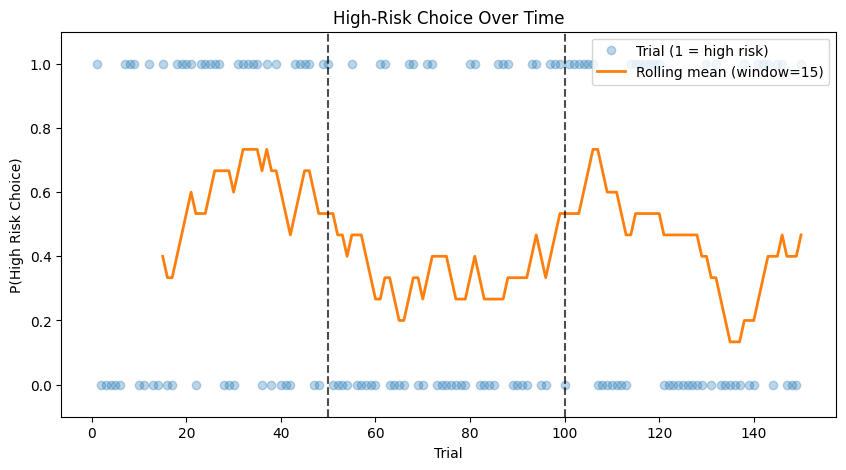

In [30]:
# Check how choices changed over time
df = pd.read_csv(output_path)

df["chosen_risk"] = df.apply(
    lambda row: (
        row["symbol1_risk"] if row["chosen_symbol"] == 1 else row["symbol2_risk"]
    ),
    axis=1,
)

df["high_risk_choice"] = (df["chosen_risk"] == "high").astype(int)

df = df.sort_values("trial")

window = 15
df["rolling_high_risk"] = df["high_risk_choice"].rolling(window=window).mean()

plt.figure(figsize=(10, 5))

plt.plot(
    df["trial"],
    df["high_risk_choice"],
    marker="o",
    linestyle="none",
    alpha=0.3,
    label="Trial (1 = high risk)",
)

plt.plot(
    
    df["trial"],
    df["rolling_high_risk"],
    linewidth=2,
    label=f"Rolling mean (window={window})",
)

plt.axvline(x=50, color="black", linestyle="--", alpha=0.7)
plt.axvline(x=100, color="black", linestyle="--", alpha=0.7)

plt.title("High-Risk Choice Over Time")
plt.xlabel("Trial")
plt.ylabel("P(High Risk Choice)")
plt.ylim(-0.1, 1.1)
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Statistical test on how the proportion of high risk choices changed between the blocks
df = pd.read_csv(output_path)

# Determine whether the chosen option was high risk
df["chosen_risk"] = df.apply(
    lambda row: (
        row["symbol1_risk"] if row["chosen_symbol"] == 1 else row["symbol2_risk"]
    ),
    axis=1,
)

df["high_risk_choice"] = (df["chosen_risk"] == "high").astype(int)

# Split into 3 blocks of 50 trials
df["block"] = pd.cut(df["trial"], bins=[0, 50, 100, 150], labels=["1", "2", "3"])

for b1, b2 in [("1", "2"), ("2", "3")]:
    subset = df[df["block"].isin([b1, b2])]

    table = pd.crosstab(subset["block"], subset["high_risk_choice"])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"Block {b1} vs Block {b2}")
    print(f"Chi² = {chi2:.3f}")
    print(f"p = {p:.4f}")

    proportions = subset.groupby("block")["high_risk_choice"].mean()
    print(f"High-risk choice rate: {proportions[b1]:.2%} vs {proportions[b2]:.2%}")
    print()


            state  next_high_prob  avg_alt_feedback  count
1   High-risk WIN        0.222222          8.333333     36
0  High-risk LOSS        0.729167         10.000000     48
3    Low-risk WIN        0.648148          6.333333     54
2   Low-risk LOSS        0.636364          6.545455     11


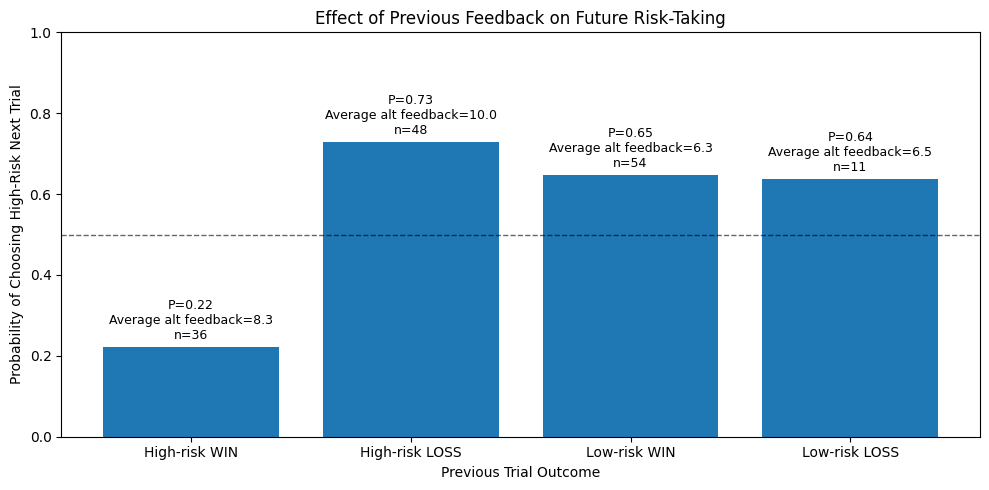

In [16]:
# Compute probability of choosing high risk depending on n-1 trial feedback.
# NOTE: Calculates n-1 trials, because it is impossible to calculate the probability for trial 1 as it does not have previous feedback.
df = pd.read_csv(output_path)

df["chosen_risk"] = df.apply(
    lambda r: r["symbol1_risk"] if r["chosen_symbol"] == 1 else r["symbol2_risk"],
    axis=1,
)

df["high_risk_choice"] = (df["chosen_risk"] == "high").astype(int)
df["win"] = (df["feedback"] > 0).astype(int)
df["next_high_risk"] = df["high_risk_choice"].shift(-1)
df_valid = df.iloc[:-1].copy()


def label_state(row):

    risk = "High" if row["chosen_risk"] == "high" else "Low"
    outcome = "WIN" if row["win"] == 1 else "LOSS"

    return f"{risk}-risk {outcome}"


df_valid["state"] = df_valid.apply(label_state, axis=1)

summary = (
    df_valid.groupby("state")
    .agg(
        next_high_prob=("next_high_risk", "mean"),
        avg_alt_feedback=("alt_feedback", "mean"),
        count=("state", "count"),
    )
    .reset_index()
)

order = ["High-risk WIN", "High-risk LOSS", "Low-risk WIN", "Low-risk LOSS"]

summary["state"] = pd.Categorical(summary["state"], categories=order, ordered=True)

summary = summary.sort_values("state")

print(summary)

plt.figure(figsize=(10, 5))

bars = plt.bar(summary["state"], summary["next_high_prob"])

plt.axhline(y=0.5, linestyle="--", linewidth=1, color="black", alpha=0.6)

for bar, (_, row) in zip(bars, summary.iterrows()):
    text = (
        f"P={row['next_high_prob']:.2f}\n"
        f"Average alt feedback={row['avg_alt_feedback']:.1f}\n"
        f"n={row['count']}"
    )

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        text,
        ha="center",
        fontsize=9,
    )

plt.ylim(0, 1)

plt.ylabel("Probability of Choosing High-Risk Next Trial")
plt.xlabel("Previous Trial Outcome")

plt.title("Effect of Previous Feedback on Future Risk-Taking")

plt.tight_layout()
plt.show()

In [ ]:
# Check statistical significance of feedback on next choice
df = pd.read_csv(output_path)

df["chosen_risk"] = df.apply(
    lambda r: r["symbol1_risk"] if r["chosen_symbol"] == 1 else r["symbol2_risk"],
    axis=1,
)

df["high_risk_choice"] = (df["chosen_risk"] == "high").astype(int)
df["win"] = (df["feedback"] > 0).astype(int)

df["next_high_risk"] = df["high_risk_choice"].shift(-1)
df_valid = df.iloc[:-1].copy()

def label_state(row):
    risk = "High" if row["chosen_risk"] == "high" else "Low"
    outcome = "WIN" if row["win"] == 1 else "LOSS"
    return f"{risk}-risk {outcome}"

df_valid["state"] = df_valid.apply(label_state, axis=1)

table = pd.crosstab(df_valid["state"], df_valid["next_high_risk"])

chi2, p, dof, expected = chi2_contingency(table)

print("Effect of previous trial state on next risk choice")
print(f"Chi² = {chi2:.3f}")
print(f"p-value = {p:.4f}")



In [26]:
# Statistical test to check if each condition is significantly different from random chance

df = pd.read_csv(output_path)

df["chosen_risk"] = df.apply(
    lambda r: r["symbol1_risk"] if r["chosen_symbol"] == 1 else r["symbol2_risk"],
    axis=1
)

df["next_high_risk"] = (df["chosen_risk"] == "high").astype(int).shift(-1)

df_valid = df.iloc[:-1].copy()

df_valid["state"] = df_valid.apply(
    lambda r: f"{'High' if r['chosen_risk']=='high' else 'Low'}-risk "
              f"{'WIN' if r['feedback']>0 else 'LOSS'}",
    axis=1
)

for state, g in df_valid.groupby("state"):

    n_high = int(g["next_high_risk"].sum())
    n = int(len(g))

    p = binomtest(n_high, n, p=0.5).pvalue

    print(state, "p-value =", round(p, 4), "(", n_high, "/", n, ")")

High-risk LOSS p-value = 0.0021 ( 35 / 48 )
High-risk WIN p-value = 0.0012 ( 8 / 36 )
Low-risk LOSS p-value = 0.5488 ( 7 / 11 )
Low-risk WIN p-value = 0.0402 ( 35 / 54 )
